In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import TimeSeriesDataset, FeatureDescription
from model import TemporalFusionTransformer
from utils import load_config, find_quantile_index, unscale_per_id

In [2]:
CHECKPOINT_PATH = "runs/20251227-095115/checkpoints/best.pt" 
CONFIG_PATH = "config.yaml"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
print("Loading configuration and data...")
config = load_config(CONFIG_PATH)
feature_cfg = config["feature_description"]
model_cfg = config["model"]
dataset_cfg = config["dataset"]

# Define Feature Description
feature_description = FeatureDescription(
    id=feature_cfg["id"],
    time=feature_cfg["time"],
    target=feature_cfg["target"],
    known_continuous=feature_cfg.get("known_continuous", []),
    known_categorical=feature_cfg.get("known_categorical", []),
    static_categorical=feature_cfg.get("static_categorical", []),
    static_continuous=feature_cfg.get("static_continuous", []),
    observed_continuous=feature_cfg.get("observed_continuous", []),
    observed_categorical=feature_cfg.get("observed_categorical", []),
)

target_col = feature_description.target
if target_col not in feature_description.observed_continuous:
    print(f"Auto-adding target '{target_col}' to observed_continuous features.")
    feature_description.observed_continuous.append(target_col)

# Load Data
df = pd.read_csv(dataset_cfg["path"])

# Create train dataset first to fit scalers correctly
train_boundary = dataset_cfg["valid_boundary"]
df_train = df[df["days_from_start"] < train_boundary]

train_dataset = TimeSeriesDataset(
    df=df_train,
    feature_description=feature_description,
    encoder_length=model_cfg["encoder_length"],
    decoder_length=model_cfg["decoder_length"],
)

# Fit encoders/scalers on training data
categorical_encoder = train_dataset.categorical_encoder
real_scalers, target_scalers = TimeSeriesDataset.get_scalers(train_dataset)
target_scalers_by_id = {str(k): v for k, v in target_scalers.items()}

# Create test dataset
test_boundary = dataset_cfg["test_boundary"]
df_test = df[df["days_from_start"] >= test_boundary - 7] # -7 overlap for context

test_dataset = TimeSeriesDataset(
    df=df_test,
    feature_description=feature_description,
    encoder_length=model_cfg["encoder_length"],
    decoder_length=model_cfg["decoder_length"],
    categorical_encoder=categorical_encoder,
)

# Apply the training scalers to test data
test_dataset.apply_scalers(real_scalers, target_scalers)

test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=0 # Set to 0 for debugging in notebooks
)

Loading configuration and data...
Auto-adding target 'power_usage' to observed_continuous features.


In [4]:
print("Loading model...")
params = {
    "encoder_length": model_cfg["encoder_length"],
    "decoder_length": model_cfg["decoder_length"],
    "time_steps": test_dataset.time_steps,
    "feature_description": feature_description,
    "embed_per_cat": test_dataset.get_embedding_per_cat(),
    "d_model": model_cfg["d_model"],
    "dropout": model_cfg["dropout"],
    "n_head": model_cfg["n_head"],
    "quantiles": model_cfg["quantiles"],
}

model = TemporalFusionTransformer(params).to(DEVICE)

# Load Weights
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    if "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    else:
        model.load_state_dict(checkpoint)
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print(f"WARNING: Checkpoint not found at {CHECKPOINT_PATH}")

Loading model...
Loaded checkpoint from runs/20251227-095115/checkpoints/best.pt


In [5]:
model.eval()
q_losses = {q: 0.0 for q in model.quantiles}
total_samples = 0
target_abs_sum = 0.0 

# Indices for P10, P50, P90
p10_idx = find_quantile_index(model.quantiles, 0.1)
p50_idx = find_quantile_index(model.quantiles, 0.5)
p90_idx = find_quantile_index(model.quantiles, 0.9)

# Store results for plotting
plot_data = []

print("Running evaluation on Test Set...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        inputs = batch["model_inputs"]
        for k, v in inputs.items():
            inputs[k] = v.to(DEVICE)
        
        batch["model_inputs"] = inputs
        targets = batch["target"].to(DEVICE) 
        ids = batch["id"]
        
        # Forward pass
        preds = model(batch) 
        
        # Unscale for accurate metrics and plotting
        preds_unscaled, targets_unscaled = unscale_per_id(preds, targets, ids, target_scalers_by_id)
        
        # Calculate qRisk 
        target_abs_sum += targets_unscaled.abs().sum().item()
        
        for i, q in enumerate(model.quantiles):
            errors = targets_unscaled - preds_unscaled[..., i:i+1]
            loss = torch.maximum(q * errors, (q - 1) * errors)
            q_losses[q] += loss.sum().item()
            
        total_samples += targets.shape[0]
        
        # Save first batch for plotting
        if len(plot_data) < 5:
            plot_data.append({
                "preds": preds_unscaled.cpu(),
                "targets": targets_unscaled.cpu(),
                "ids": ids,
                "time": batch["cut_time"]
            })

Running evaluation on Test Set...


100%|██████████| 837/837 [03:28<00:00,  4.01it/s]



=== TEST SET RESULTS ===
------------------------------
Quantile 0.1 | q-Risk: 0.02770
Quantile 0.5 | q-Risk: 0.05690
Quantile 0.9 | q-Risk: 0.02902

=== VISUALIZATION ===


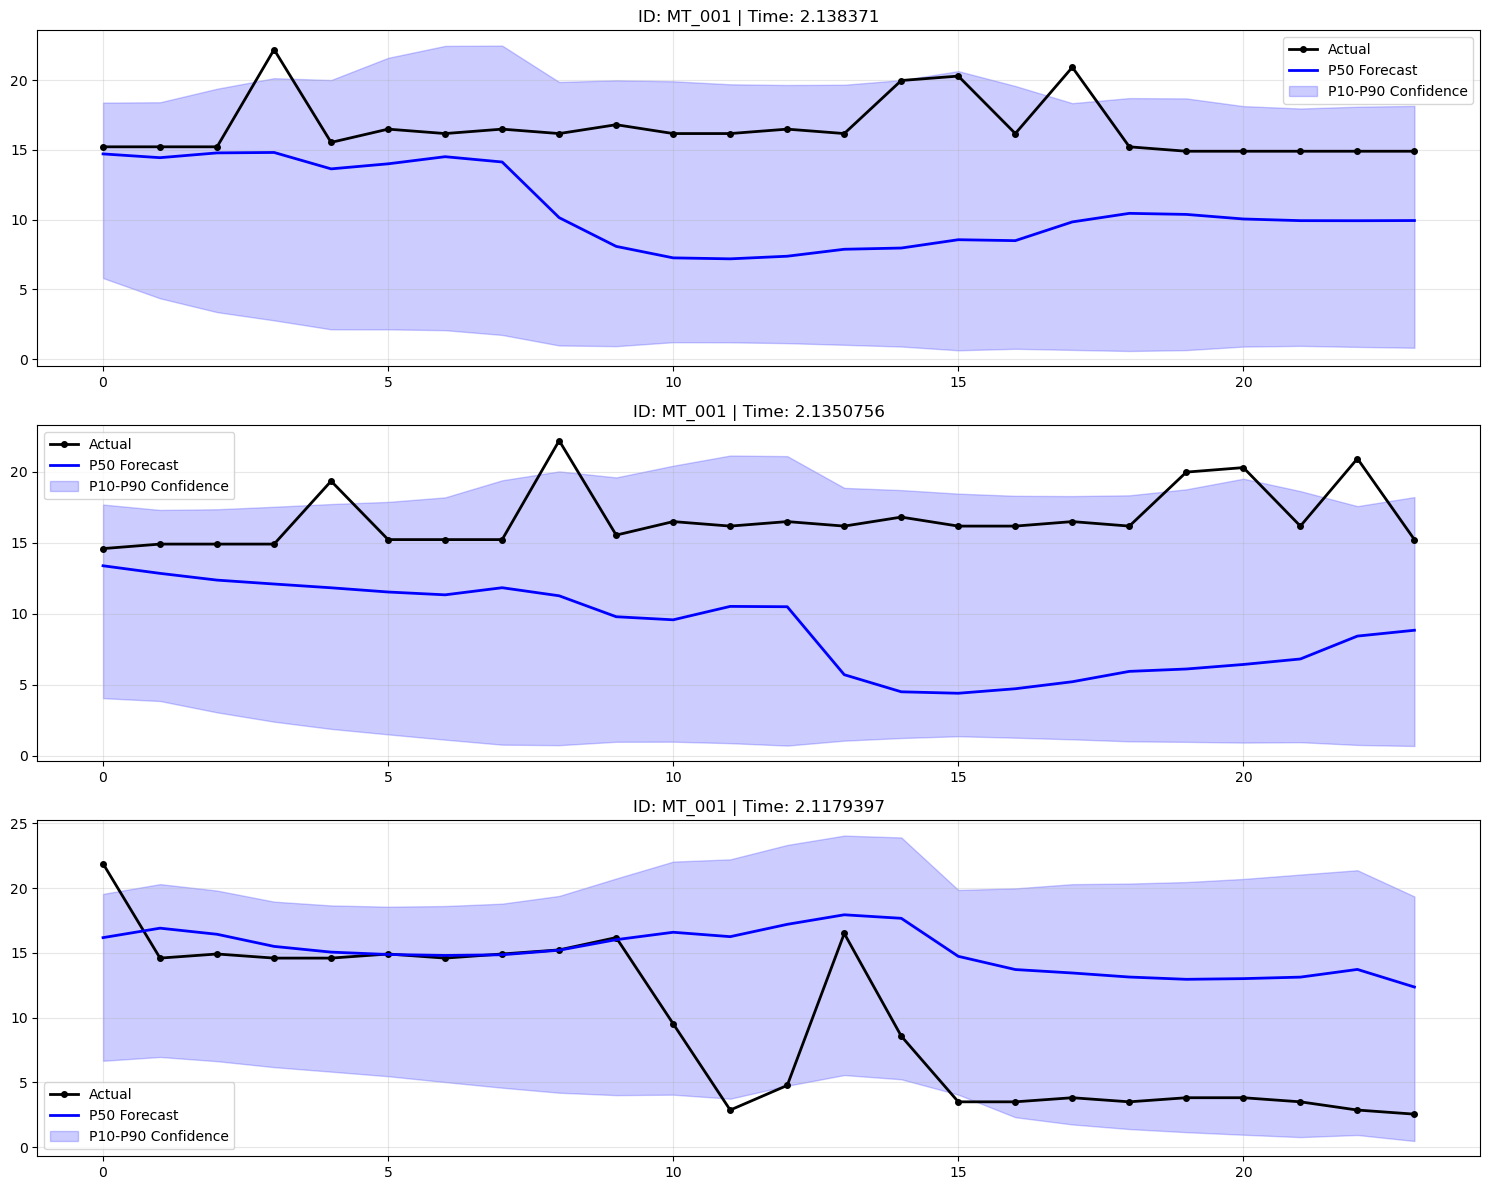

In [7]:
print("\n=== TEST SET RESULTS ===")
print("-" * 30)
for q in model.quantiles:
    # q-Risk formula: 2 * Sum(QuantileLoss) / Sum(Abs(Target))
    if target_abs_sum > 0:
        q_risk = 2.0 * q_losses[q] / target_abs_sum
        print(f"Quantile {q:.1f} | q-Risk: {q_risk:.5f}")
    else:
        print(f"Quantile {q:.1f} | q-Risk: N/A (Target abs sum is 0)")

# Plotting a few random examples
print("\n=== VISUALIZATION ===")
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Select a random batch and random index from that batch
if len(plot_data) > 0:
    batch_data = plot_data[0] 
    # Ensure we don't try to plot more samples than exist in the batch
    n_samples_in_batch = len(batch_data["ids"])
    n_plot = min(3, n_samples_in_batch)
    
    sample_indices = np.random.choice(n_samples_in_batch, n_plot, replace=False)

    for i, ax_idx in zip(sample_indices, range(n_plot)):
        ax = axes[ax_idx]
        id_str = batch_data["ids"][i]
        time_str = batch_data["time"][i]
        
        # Get data (Decoder length only)
        actual = batch_data["targets"][i, :, 0].numpy()
        p10 = batch_data["preds"][i, :, p10_idx].numpy() if p10_idx is not None else np.zeros_like(actual)
        p50 = batch_data["preds"][i, :, p50_idx].numpy() if p50_idx is not None else np.zeros_like(actual)
        p90 = batch_data["preds"][i, :, p90_idx].numpy() if p90_idx is not None else np.zeros_like(actual)
        
        x = range(len(actual))
        
        ax.plot(x, actual, label="Actual", color="black", linewidth=2, marker='o', markersize=4)
        if p50_idx is not None:
            ax.plot(x, p50, label="P50 Forecast", color="blue", linewidth=2)
        if p10_idx is not None and p90_idx is not None:
            ax.fill_between(x, p10, p90, color="blue", alpha=0.2, label="P10-P90 Confidence")
        
        ax.set_title(f"ID: {id_str} | Time: {time_str}")
        ax.legend()
        ax.grid(True, alpha=0.3)
else:
    print("No data collected for plotting.")

plt.tight_layout()
plt.show()

In [ ]:
# Visualize velib data for a station for a week
import seaborn as sns
velib_df = pd.read_csv("velib_data/velib_dataset.csv")
# transform date_seconds to datetime
velib_df['datetime'] = pd.to_datetime(velib_df['date_seconds'], unit='s')
# filter for station 10001 and a specific week
station_id = 10001
start_date = '2021-01-03'
end_date = '2021-01-10'
station_data = velib_df 
plt.figure(figsize=(15, 6))
sns.lineplot(data=station_data, x='datetime', y='available_bikes', marker='o')
plt.title(f'Available Bikes at Station {station_id} from {start_date} to {end_date}')
plt.xlabel('DateTime')
plt.ylabel('Available Bikes')
plt.grid(True, alpha=0.3)
plt.show()